<a href="https://colab.research.google.com/github/AnkithR10/HR-Analytics-Using-Machine-Learning-and-Clustering/blob/main/HR_Analytics_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HR Analytics using Machine Learning and Clustering Techniques

## DATA LOADING & INITIAL INSPECTION

In [ ]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [ ]:
#Load Dataset
df = pd.read_csv("/content/Messy_HR_Dataset_Detailed.csv")
df.head()

,Unnamed: 0,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Location,Trainer,Training Duration(Days),Training Cost
0,0,Uriah,Bridges,20-Sep-19,NaN,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Active,...,2,3,15-Jul-23,Leadership Development,Internal,Failed,South Marisa,Taylor Rodriguez,2,606.11
1,1,Paula,Small,11-Feb-23,NaN,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Active,...,1,5,12-Sep-22,Customer Service,External,Incomplete,Tammieville,Kelly Patterson DDS,4,673.02
2,2,Edward,Buck,10-Dec-18,NaN,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Active,...,2,1,13-Aug-22,Leadership Development,External,Failed,East Roberthaven,Taylor Thomas,2,413.28
3,3,Michael,Riordan,21-Jun-21,NaN,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Active,...,5,4,15-Dec-22,Project Management,External,Completed,Garzatown,Holly Elliott,3,663.78
4,4,Jasmine,Onque,29-Jun-19,NaN,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Active,...,5,3,13-Jul-23,Technical Skills,External,Failed,Lake Meganville,Donald Martinez,5,399.03


In [ ]:
# Basic Dataset Overview
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  3150 non-null   int64  
 1   FirstName                   3150 non-null   object 
 2   LastName                    3150 non-null   object 
 3   StartDate                   3150 non-null   object 
 4   ExitDate                    1606 non-null   object 
 5   Title                       3150 non-null   object 
 6   Supervisor                  3150 non-null   object 
 7   ADEmail                     3150 non-null   object 
 8   BusinessUnit                3150 non-null   object 
 9   EmployeeStatus              3150 non-null   object 
 10  EmployeeType                3150 non-null   object 
 11  PayZone                     3150 non-null   object 
 12  EmployeeClassificationType  3150 non-null   object 
 13  TerminationType             3150 

,0
Unnamed: 0,0
FirstName,0
LastName,0
StartDate,0
ExitDate,1544
Title,0
Supervisor,0
ADEmail,0
BusinessUnit,0
EmployeeStatus,0


In [ ]:
#Check Columns
df.columns

Index(['Unnamed: 0', 'FirstName', 'LastName', 'StartDate', 'ExitDate', 'Title',
       'Supervisor', 'ADEmail', 'BusinessUnit', 'EmployeeStatus',
       'EmployeeType', 'PayZone', 'EmployeeClassificationType',
       'TerminationType', 'TerminationDescription', 'DepartmentType',
       'Division', 'DOB', 'State', 'JobFunctionDescription', 'GenderCode',
       'LocationCode', 'RaceDesc', 'MaritalDesc', 'Performance Score',
       'Current Employee Rating', 'Employee ID', 'Survey Date',
       'Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score',
       'Training Date', 'Training Program Name', 'Training Type',
       'Training Outcome', 'Location', 'Trainer', 'Training Duration(Days)',
       'Training Cost'],
      dtype='object')

## DATA PREPROCESSING & HOLDOUT VALIDATION

In [ ]:
# Dropping Irrelevant Columns
drop_cols = [
    'Unnamed: 0', 'FirstName', 'LastName', 'ADEmail',
    'Employee ID', 'StartDate', 'ExitDate', 'DOB',
    'Survey Date', 'Training Date',
    'TerminationDescription'
]

df = df.drop(columns=drop_cols)
df['EmployeeStatus'] = df['EmployeeStatus'].apply(
    lambda x: 0 if 'Active' in x else 1
)

# Defining Target Variables
y_clf = df['EmployeeStatus']
df['ranking_score'] = (
    df['Current Employee Rating'] * 2 +
    df['Engagement Score'] +
    df['Satisfaction Score'] +
    df['Work-Life Balance Score']
)

# Feature Engineering (Ranking Score)
y_reg = df['ranking_score']
X = df.drop(['EmployeeStatus', 'ranking_score'], axis=1)
X = X.fillna("Unknown")
X = pd.get_dummies(X, drop_first=True)

In [ ]:
# MULTIPLE HOLDOUT SPLITS - REGULAR DATA

from sklearn.model_selection import train_test_split
split_ratios = [0.2, 0.3, 0.335, 0.4]
regular_splits = {}

for test_size in split_ratios:
    X_train, X_test, y_clf_train, y_clf_test = train_test_split(X, y_clf, test_size=test_size, random_state=42)

    # For regression
    y_reg_train = y_reg.loc[y_clf_train.index]
    y_reg_test  = y_reg.loc[y_clf_test.index]

    key = f"{int((1-test_size)*100)}:{int(test_size*100)}"
    regular_splits[key] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train_clf": y_clf_train,
        "y_test_clf": y_clf_test,
        "y_train_reg": y_reg_train,
        "y_test_reg": y_reg_test
    }

    print(f"\nSplit Ratio {key}")
    print("X_train:", X_train.shape, "| X_test:", X_test.shape)


Split Ratio 80:20
X_train: (2520, 8843) | X_test: (630, 8843)

Split Ratio 70:30
X_train: (2205, 8843) | X_test: (945, 8843)

Split Ratio 66:33
X_train: (2094, 8843) | X_test: (1056, 8843)

Split Ratio 60:40
X_train: (1890, 8843) | X_test: (1260, 8843)


In [ ]:
# DATASET OVERVIEW

print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns)

Shape of dataset: (3150, 29)

Column names:
 Index(['Title', 'Supervisor', 'BusinessUnit', 'EmployeeStatus', 'EmployeeType',
       'PayZone', 'EmployeeClassificationType', 'TerminationType',
       'DepartmentType', 'Division', 'State', 'JobFunctionDescription',
       'GenderCode', 'LocationCode', 'RaceDesc', 'MaritalDesc',
       'Performance Score', 'Current Employee Rating', 'Engagement Score',
       'Satisfaction Score', 'Work-Life Balance Score',
       'Training Program Name', 'Training Type', 'Training Outcome',
       'Location', 'Trainer', 'Training Duration(Days)', 'Training Cost',
       'ranking_score'],
      dtype='object')


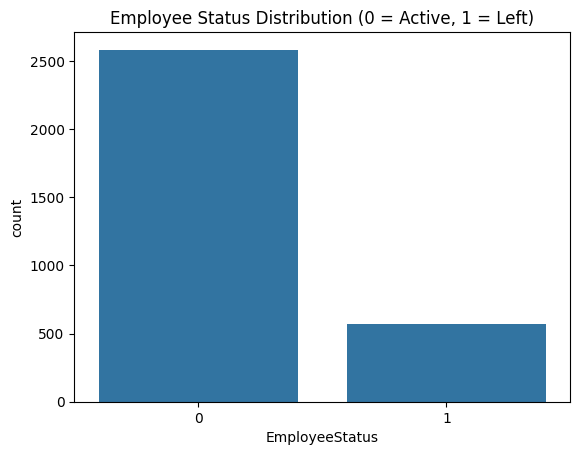

In [ ]:
#TARGET VARIABLE DISTRIBUTION

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_clf)
plt.title("Employee Status Distribution (0 = Active, 1 = Left)")
plt.show()

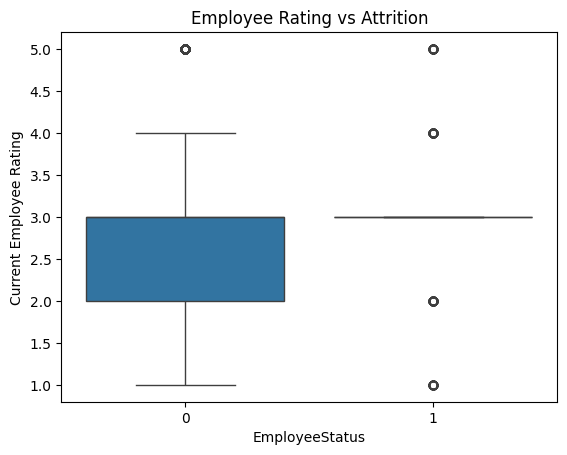

In [ ]:
# PERFORMANCE VS ATTRITION

sns.boxplot(x=y_clf, y=df['Current Employee Rating'])
plt.title("Employee Rating vs Attrition")
plt.show()

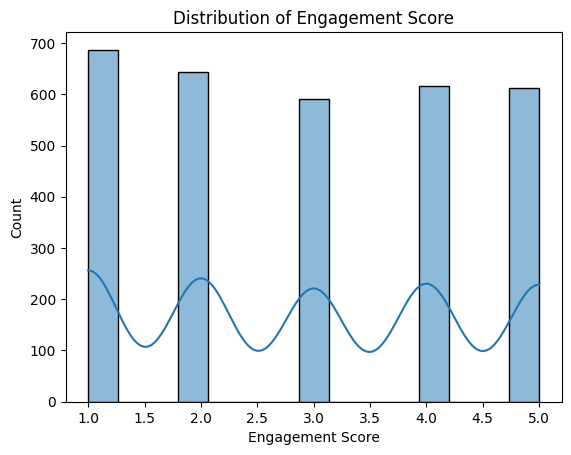

In [ ]:
# ENGAGEMENT SCORE DISTRIBUTION

sns.histplot(df['Engagement Score'], kde=True)
plt.title("Distribution of Engagement Score")
plt.show()

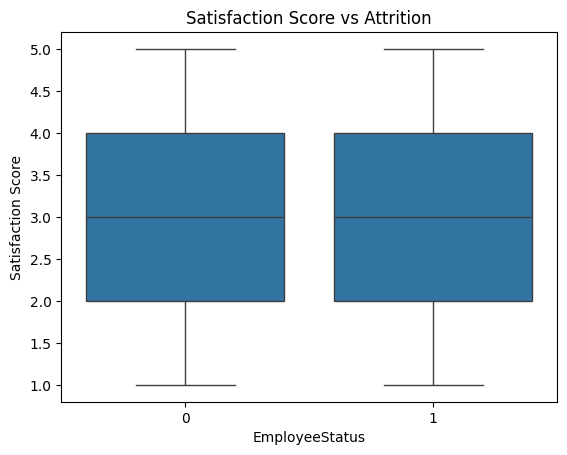

In [ ]:
# SATISFACTION VS ATTRITION

sns.boxplot(x=y_clf, y=df['Satisfaction Score'])
plt.title("Satisfaction Score vs Attrition")
plt.show()

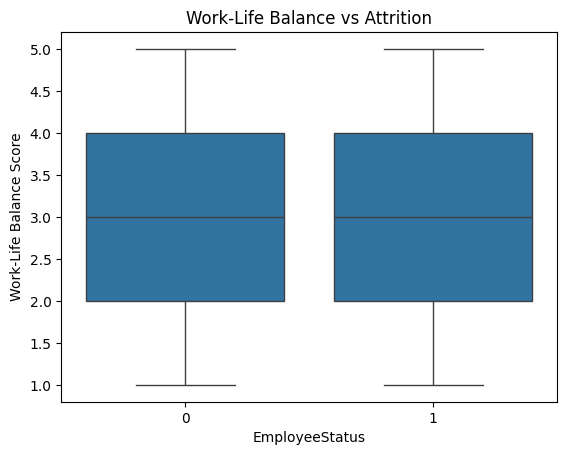

In [ ]:
# WORK-LIFE BALANCE ANALYSIS

sns.boxplot(x=y_clf, y=df['Work-Life Balance Score'])
plt.title("Work-Life Balance vs Attrition")
plt.show()

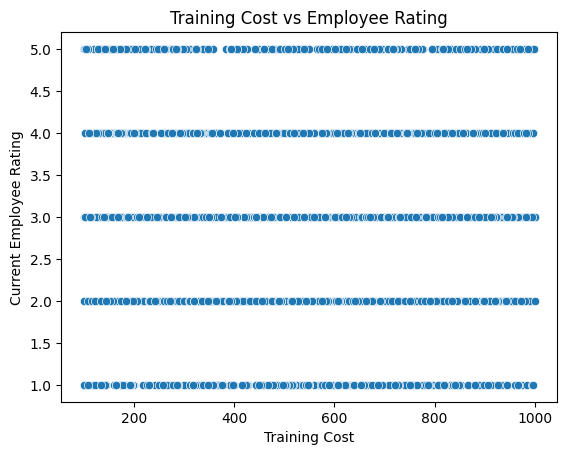

In [ ]:
# TRAINING COST VS PERFORMANCE

sns.scatterplot(x=df['Training Cost'], y=df['Current Employee Rating'])
plt.title("Training Cost vs Employee Rating")
plt.show()

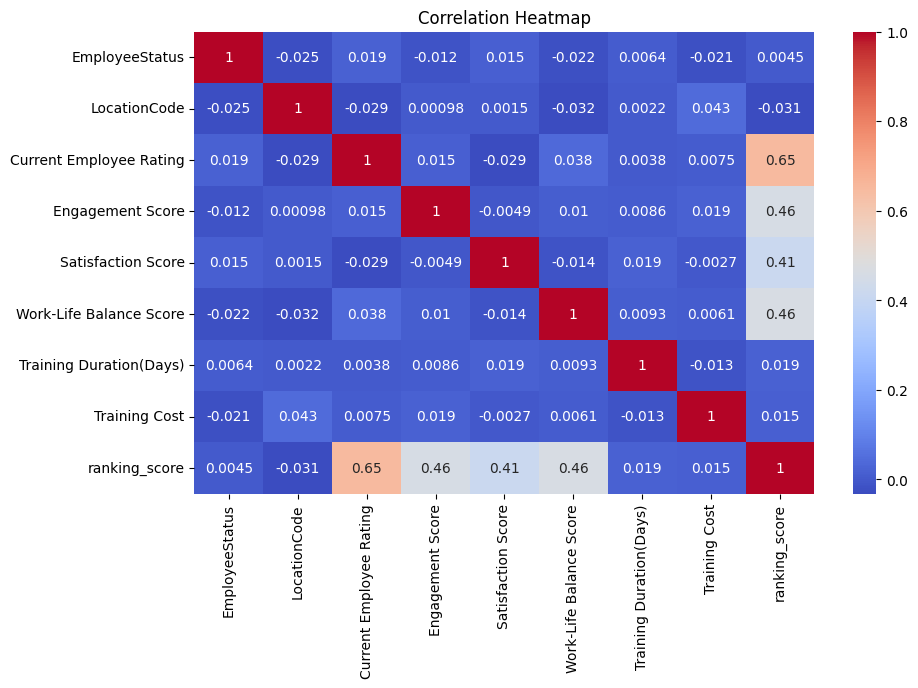

In [ ]:
# CORRELATION HEATMAP
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##Exploratory Data Analysis

In [ ]:
# FEATURE SCALING
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
 #PCA
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

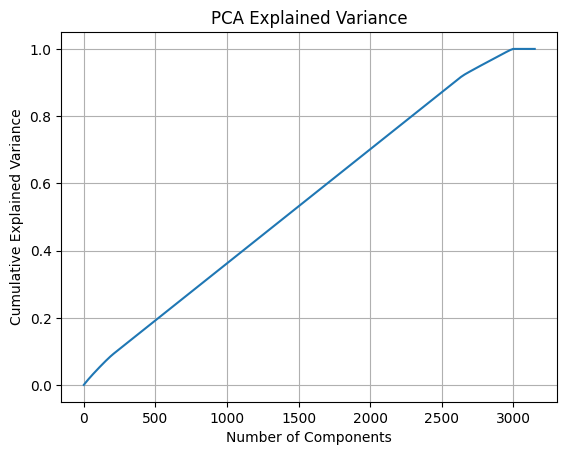

In [ ]:
# EXPLAINED VARIANCE ANALYSIS
import numpy as np
explained_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(explained_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

In [ ]:
# SELECT OPTIMAL COMPONENTS
n_components = np.argmax(explained_variance >= 0.95) + 1
print("Optimal number of components:", n_components)

Optimal number of components: 2772


In [ ]:
# FINAL PCA TRANSFORMATION
pca_final = PCA(n_components=n_components)
X_pca_final = pca_final.fit_transform(X_scaled)

In [ ]:
# MULTIPLE HOLDOUT SPLITS - PCA DATA
pca_splits = {}
for test_size in split_ratios:
    X_train_pca, X_test_pca, y_clf_train, y_clf_test = train_test_split(X_pca_final, y_clf, test_size=test_size, random_state=42)
    y_reg_train = y_reg.loc[y_clf_train.index]
    y_reg_test  = y_reg.loc[y_clf_test.index]

    key = f"{int((1-test_size)*100)}:{int(test_size*100)}"

    pca_splits[key] = {
        "X_train": X_train_pca,
        "X_test": X_test_pca,
        "y_train_clf": y_clf_train,
        "y_test_clf": y_clf_test,
        "y_train_reg": y_reg_train,
        "y_test_reg": y_reg_test
    }
    print(f"\nPCA Split Ratio {key}")
    print("X_train:", X_train_pca.shape, "| X_test:", X_test_pca.shape)


PCA Split Ratio 80:20
X_train: (2520, 2772) | X_test: (630, 2772)

PCA Split Ratio 70:30
X_train: (2205, 2772) | X_test: (945, 2772)

PCA Split Ratio 66:33
X_train: (2094, 2772) | X_test: (1056, 2772)

PCA Split Ratio 60:40
X_train: (1890, 2772) | X_test: (1260, 2772)


##LINEAR REGRESSION

In [ ]:
# Import Required Libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Store results
lr_results = {
    "regular": {},
    "pca": {}
}

In [ ]:
# LINEAR REGRESSION - REGULAR DATA
for split_name, data in regular_splits.items():
    X_train = data["X_train"]
    X_test  = data["X_test"]
    y_train = data["y_train_reg"]
    y_test  = data["y_test_reg"]

    # Train Model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    sse = np.sum((y_test - y_pred) ** 2)
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)

    # Store Results
    lr_results["regular"][split_name] = {
        "SSE": sse,
        "MSE": mse,
        "R2": r2
    }

    # Print Results
    print(f"\nSplit {split_name}")
    print(f"SSE: {sse:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R2:  {r2:.4f}")


Split 80:20
SSE: 0.00
MSE: 0.00
R2:  1.0000

Split 70:30
SSE: 0.01
MSE: 0.00
R2:  1.0000

Split 66:33
SSE: 0.01
MSE: 0.00
R2:  1.0000

Split 60:40
SSE: 0.02
MSE: 0.00
R2:  1.0000


In [ ]:
# LINEAR REGRESSION - PCA DATA
for split_name, data in pca_splits.items():
    X_train = data["X_train"]
    X_test  = data["X_test"]
    y_train = data["y_train_reg"]
    y_test  = data["y_test_reg"]

    # Train Model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    sse = np.sum((y_test - y_pred) ** 2)
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)

    # Store Results
    lr_results["pca"][split_name] = {
        "SSE": sse,
        "MSE": mse,
        "R2": r2
    }

    # Print Results
    print(f"\n[PCA] Split {split_name}")
    print(f"SSE: {sse:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R2:  {r2:.4f}")


[PCA] Split 80:20
SSE: 229959.72
MSE: 365.02
R2:  -33.9828

[PCA] Split 70:30
SSE: 119753.54
MSE: 126.72
R2:  -10.9508

[PCA] Split 66:33
SSE: 101869.10
MSE: 96.47
R2:  -8.1227

[PCA] Split 60:40
SSE: 34813.87
MSE: 27.63
R2:  -1.6058


In [ ]:
# RESULTS SUMMARY TABLE
import pandas as pd
def results_to_df(results_dict, label):
    rows = []
    for split, metrics in results_dict.items():
        row = {"Type": label, "Split": split}
        row.update(metrics)
        rows.append(row)
    return pd.DataFrame(rows)

df_regular = results_to_df(lr_results["regular"], "Regular")
df_pca     = results_to_df(lr_results["pca"], "PCA")
final_results = pd.concat([df_regular, df_pca], ignore_index=True)
final_results

,Type,Split,SSE,MSE,R2
0,Regular,80:20,0.004692,0.000007,0.999999
1,Regular,70:30,0.010743,0.000011,0.999999
2,Regular,66:33,0.013412,0.000013,0.999999
3,Regular,60:40,0.020353,0.000016,0.999998
4,PCA,80:20,229959.715826,365.015422,-33.982843
5,PCA,70:30,119753.544237,126.723327,-10.950815
6,PCA,66:33,101869.100950,96.466952,-8.122668
7,PCA,60:40,34813.869335,27.630055,-1.605764


##BIAS-VARIANCE TRADEOFF ANALYSIS

In [ ]:
# Storage for Bias-Variance Results
bv_results = {
    "regular": {},
    "pca": {}
}

In [ ]:
# BIAS-VARIANCE ANALYSIS - REGULAR DATA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

for split_name, data in regular_splits.items():
    X_train = data["X_train"]
    X_test  = data["X_test"]
    y_train = data["y_train_reg"]
    y_test  = data["y_test_reg"]
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # Errors
    train_error = mean_squared_error(y_train, y_train_pred)
    test_error  = mean_squared_error(y_test, y_test_pred)

    # Store Results
    bv_results["regular"][split_name] = {
        "Train Error": train_error,
        "Test Error": test_error
    }

    print(f"\nRegular Split {split_name}")
    print(f"Train Error: {train_error:.2f}")
    print(f"Test Error:  {test_error:.2f}")


Regular Split 80:20
Train Error: 0.00
Test Error:  0.00

Regular Split 70:30
Train Error: 0.00
Test Error:  0.00

Regular Split 66:33
Train Error: 0.00
Test Error:  0.00

Regular Split 60:40
Train Error: 0.00
Test Error:  0.00


In [ ]:
# BIAS-VARIANCE ANALYSIS - PCA DATA
for split_name, data in pca_splits.items():

    X_train = data["X_train"]
    X_test  = data["X_test"]
    y_train = data["y_train_reg"]
    y_test  = data["y_test_reg"]

    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # Errors
    train_error = mean_squared_error(y_train, y_train_pred)
    test_error  = mean_squared_error(y_test, y_test_pred)

    # Store Results
    bv_results["pca"][split_name] = {
        "Train Error": train_error,
        "Test Error": test_error
    }

    print(f"\n[PCA] Split {split_name}")
    print(f"Train Error: {train_error:.2f}")
    print(f"Test Error:  {test_error:.2f}")


[PCA] Split 80:20
Train Error: 0.00
Test Error:  365.02

[PCA] Split 70:30
Train Error: 0.00
Test Error:  126.72

[PCA] Split 66:33
Train Error: 0.00
Test Error:  96.47

[PCA] Split 60:40
Train Error: 0.00
Test Error:  27.63


In [ ]:
# BIAS-VARIANCE RESULTS TABLE
def bv_to_df(results_dict, label):
    rows = []
    for split, metrics in results_dict.items():
        row = {"Type": label, "Split": split}
        row.update(metrics)
        rows.append(row)
    return pd.DataFrame(rows)

bv_regular_df = bv_to_df(bv_results["regular"], "Regular")
bv_pca_df     = bv_to_df(bv_results["pca"], "PCA")

bv_final = pd.concat([bv_regular_df, bv_pca_df], ignore_index=True)
bv_final

,Type,Split,Train Error,Test Error
0,Regular,80:20,4.092903e-23,0.000007
1,Regular,70:30,1.834699e-22,0.000011
2,Regular,66:33,7.722031e-22,0.000013
3,Regular,60:40,2.333588e-23,0.000016
4,PCA,80:20,1.152458e-27,365.015422
5,PCA,70:30,5.189088e-28,126.723327
6,PCA,66:33,3.974488e-28,96.466952
7,PCA,60:40,2.040220e-28,27.630055


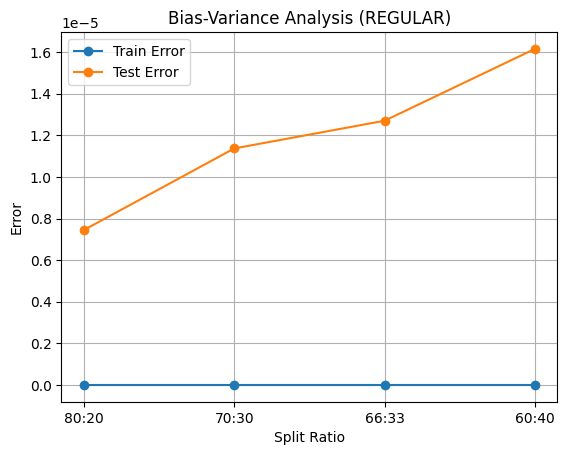

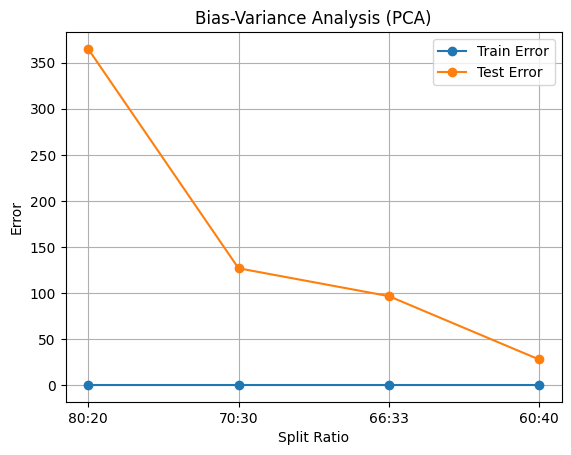

In [ ]:
# TRAIN vs TEST ERROR VISUALIZATION
import matplotlib.pyplot as plt

for data_type in ["regular", "pca"]:

    df_plot = bv_to_df(bv_results[data_type], data_type)

    plt.figure()
    plt.plot(df_plot["Split"], df_plot["Train Error"], marker='o', label="Train Error")
    plt.plot(df_plot["Split"], df_plot["Test Error"], marker='o', label="Test Error")

    plt.title(f"Bias-Variance Analysis ({data_type.upper()})")
    plt.xlabel("Split Ratio")
    plt.ylabel("Error")
    plt.legend()
    plt.grid()
    plt.show()

## REGULARIZATION (RIDGE & LASSO)

In [ ]:
# Import Regularization Models
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Store results
reg_results = {
    "regular": {},
    "pca": {}
}

# Regularization strength values
alphas = [0.01, 0.1, 1, 10]

In [ ]:
# RIDGE & LASSO - REGULAR DATA
for split_name, data in regular_splits.items():

    X_train = data["X_train"]
    X_test  = data["X_test"]
    y_train = data["y_train_reg"]
    y_test  = data["y_test_reg"]

    reg_results["regular"][split_name] = {}

    for alpha in alphas:
        # Ridge Regression
        ridge = Ridge(alpha=alpha)
        ridge.fit(X_train, y_train)
        y_pred_ridge = ridge.predict(X_test)

        # Lasso Regression
        lasso = Lasso(alpha=alpha)
        lasso.fit(X_train, y_train)
        y_pred_lasso = lasso.predict(X_test)

        # Store Metrics
        reg_results["regular"][split_name][f"alpha={alpha}"] = {
            "Ridge_MSE": mean_squared_error(y_test, y_pred_ridge),
            "Ridge_R2":  r2_score(y_test, y_pred_ridge),
            "Lasso_MSE": mean_squared_error(y_test, y_pred_lasso),
            "Lasso_R2":  r2_score(y_test, y_pred_lasso)
        }

        print(f"\n[REGULAR] Split {split_name} | alpha={alpha}")
        print(f"Ridge R2: {r2_score(y_test, y_pred_ridge):.4f}")
        print(f"Lasso R2: {r2_score(y_test, y_pred_lasso):.4f}")


[REGULAR] Split 80:20 | alpha=0.01
Ridge R2: 1.0000
Lasso R2: 1.0000

[REGULAR] Split 80:20 | alpha=0.1
Ridge R2: 1.0000
Lasso R2: 0.9976

[REGULAR] Split 80:20 | alpha=1
Ridge R2: 1.0000
Lasso R2: 0.7565

[REGULAR] Split 80:20 | alpha=10
Ridge R2: 1.0000
Lasso R2: -0.0037

[REGULAR] Split 70:30 | alpha=0.01
Ridge R2: 1.0000
Lasso R2: 1.0000

[REGULAR] Split 70:30 | alpha=0.1
Ridge R2: 1.0000
Lasso R2: 0.9975

[REGULAR] Split 70:30 | alpha=1
Ridge R2: 1.0000
Lasso R2: 0.7530

[REGULAR] Split 70:30 | alpha=10
Ridge R2: 1.0000
Lasso R2: -0.0030

[REGULAR] Split 66:33 | alpha=0.01
Ridge R2: 1.0000
Lasso R2: 1.0000

[REGULAR] Split 66:33 | alpha=0.1
Ridge R2: 1.0000
Lasso R2: 0.9975

[REGULAR] Split 66:33 | alpha=1
Ridge R2: 1.0000
Lasso R2: 0.7530

[REGULAR] Split 66:33 | alpha=10
Ridge R2: 1.0000
Lasso R2: -0.0019

[REGULAR] Split 60:40 | alpha=0.01
Ridge R2: 1.0000
Lasso R2: 1.0000

[REGULAR] Split 60:40 | alpha=0.1
Ridge R2: 1.0000
Lasso R2: 0.9975

[REGULAR] Split 60:40 | alpha=1
Rid

In [ ]:
# RIDGE & LASSO - PCA DATA
for split_name, data in pca_splits.items():

    X_train = data["X_train"]
    X_test  = data["X_test"]
    y_train = data["y_train_reg"]
    y_test  = data["y_test_reg"]

    reg_results["pca"][split_name] = {}

    for alpha in alphas:
        # Ridge
        ridge = Ridge(alpha=alpha)
        ridge.fit(X_train, y_train)
        y_pred_ridge = ridge.predict(X_test)

        # Lasso
        lasso = Lasso(alpha=alpha)
        lasso.fit(X_train, y_train)
        y_pred_lasso = lasso.predict(X_test)

        # Store Metrics
        reg_results["pca"][split_name][f"alpha={alpha}"] = {
            "Ridge_MSE": mean_squared_error(y_test, y_pred_ridge),
            "Ridge_R2":  r2_score(y_test, y_pred_ridge),
            "Lasso_MSE": mean_squared_error(y_test, y_pred_lasso),
            "Lasso_R2":  r2_score(y_test, y_pred_lasso)
        }

        print(f"\n[PCA] Split {split_name} | alpha={alpha}")
        print(f"Ridge R2: {r2_score(y_test, y_pred_ridge):.4f}")
        print(f"Lasso R2: {r2_score(y_test, y_pred_lasso):.4f}")


[PCA] Split 80:20 | alpha=0.01
Ridge R2: -22.3609
Lasso R2: 0.9514

[PCA] Split 80:20 | alpha=0.1
Ridge R2: -20.7417
Lasso R2: 0.9119

[PCA] Split 80:20 | alpha=1
Ridge R2: -13.3894
Lasso R2: 0.0904

[PCA] Split 80:20 | alpha=10
Ridge R2: -2.1757
Lasso R2: -0.0005

[PCA] Split 70:30 | alpha=0.01
Ridge R2: -6.9057
Lasso R2: 0.9588

[PCA] Split 70:30 | alpha=0.1
Ridge R2: -6.3015
Lasso R2: 0.9139

[PCA] Split 70:30 | alpha=1
Ridge R2: -4.0288
Lasso R2: 0.0819

[PCA] Split 70:30 | alpha=10
Ridge R2: -0.4864
Lasso R2: -0.0037

[PCA] Split 66:33 | alpha=0.01
Ridge R2: -5.1253
Lasso R2: 0.9586

[PCA] Split 66:33 | alpha=0.1
Ridge R2: -4.6408
Lasso R2: 0.9119

[PCA] Split 66:33 | alpha=1
Ridge R2: -2.9139
Lasso R2: 0.0835

[PCA] Split 66:33 | alpha=10
Ridge R2: -0.2734
Lasso R2: -0.0016

[PCA] Split 60:40 | alpha=0.01
Ridge R2: -1.4215
Lasso R2: 0.9548

[PCA] Split 60:40 | alpha=0.1
Ridge R2: -1.1408
Lasso R2: 0.9018

[PCA] Split 60:40 | alpha=1
Ridge R2: -0.5723
Lasso R2: 0.0860

[PCA] Spli

In [ ]:
# REGULARIZATION RESULTS SUMMARY
rows = []
for data_type in ["regular", "pca"]:
    for split, alpha_data in reg_results[data_type].items():
        for alpha_key, metrics in alpha_data.items():
            row = {
                "Type": data_type,
                "Split": split,
                "Alpha": alpha_key
            }
            row.update(metrics)
            rows.append(row)

reg_df = pd.DataFrame(rows)
reg_df

,Type,Split,Alpha,Ridge_MSE,Ridge_R2,Lasso_MSE,Lasso_R2
0,regular,80:20,alpha=0.01,0.000007,0.999999,0.000254,0.999976
1,regular,80:20,alpha=0.1,0.000008,0.999999,0.025402,0.997565
2,regular,80:20,alpha=1,0.000013,0.999999,2.540189,0.756550
3,regular,80:20,alpha=10,0.000148,0.999986,10.472374,-0.003666
4,regular,70:30,alpha=0.01,0.000011,0.999999,0.000262,0.999975
5,regular,70:30,alpha=0.1,0.000012,0.999999,0.026195,0.997530
6,regular,70:30,alpha=1,0.000020,0.999998,2.619548,0.752960
7,regular,70:30,alpha=10,0.000215,0.999980,10.635305,-0.002977
8,regular,66:33,alpha=0.01,0.000013,0.999999,0.000261,0.999975
9,regular,66:33,alpha=0.1,0.000014,0.999999,0.026119,0.997530


##LOGISTIC REGRESSION

In [ ]:
# Import Required Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Store results
log_results = {
    "regular": {},
    "pca": {}
}

In [ ]:
# LOGISTIC REGRESSION - REGULAR DATA (COMPARISON)
from sklearn.preprocessing import StandardScaler

for split_name, data in regular_splits.items():
    X_train = data["X_train"]
    X_test  = data["X_test"]
    y_train = data["y_train_clf"]
    y_test  = data["y_test_clf"]

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # MODEL 1: WITHOUT CLASS BALANCING
    model_default = LogisticRegression(max_iter=5000)
    model_default.fit(X_train_scaled, y_train)
    y_pred_default = model_default.predict(X_test_scaled)

    # Metrics
    acc_d  = accuracy_score(y_test, y_pred_default)
    prec_d = precision_score(y_test, y_pred_default, zero_division=0)
    rec_d  = recall_score(y_test, y_pred_default, zero_division=0)
    f1_d   = f1_score(y_test, y_pred_default, zero_division=0)

    # MODEL 2: WITH CLASS BALANCING
    model_balanced = LogisticRegression(max_iter=5000, class_weight='balanced')
    model_balanced.fit(X_train_scaled, y_train)
    y_pred_balanced = model_balanced.predict(X_test_scaled)

    # Metrics
    acc_b  = accuracy_score(y_test, y_pred_balanced)
    prec_b = precision_score(y_test, y_pred_balanced, zero_division=0)
    rec_b  = recall_score(y_test, y_pred_balanced, zero_division=0)
    f1_b   = f1_score(y_test, y_pred_balanced, zero_division=0)

    # Print Comparison
    print(f"\n[REGULAR] Split {split_name}")
    print("WITHOUT BALANCING:")
    print(f"Accuracy: {acc_d:.4f}, Precision: {prec_d:.4f}, Recall: {rec_d:.4f}, F1: {f1_d:.4f}")
    print("WITH BALANCING:")
    print(f"Accuracy: {acc_b:.4f}, Precision: {prec_b:.4f}, Recall: {rec_b:.4f}, F1: {f1_b:.4f}")


[REGULAR] Split 80:20
WITHOUT BALANCING:
Accuracy: 0.8206, Precision: 1.0000, Recall: 0.1102, F1: 0.1986
WITH BALANCING:
Accuracy: 0.8190, Precision: 0.8824, Recall: 0.1181, F1: 0.2083

[REGULAR] Split 70:30
WITHOUT BALANCING:
Accuracy: 0.8265, Precision: 1.0000, Recall: 0.1038, F1: 0.1881
WITH BALANCING:
Accuracy: 0.8254, Precision: 0.9500, Recall: 0.1038, F1: 0.1872

[REGULAR] Split 66:33
WITHOUT BALANCING:
Accuracy: 0.8220, Precision: 1.0000, Recall: 0.0829, F1: 0.1532
WITH BALANCING:
Accuracy: 0.8210, Precision: 0.9444, Recall: 0.0829, F1: 0.1525

[REGULAR] Split 60:40
WITHOUT BALANCING:
Accuracy: 0.8238, Precision: 1.0000, Recall: 0.0633, F1: 0.1190
WITH BALANCING:
Accuracy: 0.8230, Precision: 0.9375, Recall: 0.0633, F1: 0.1186


In [ ]:
# LOGISTIC REGRESSION - PCA DATA (COMPARISON)

for split_name, data in pca_splits.items():
    X_train = data["X_train"]
    X_test  = data["X_test"]
    y_train = data["y_train_clf"]
    y_test  = data["y_test_clf"]

    # MODEL 1: WITHOUT CLASS BALANCING
    model_default = LogisticRegression(max_iter=5000)
    model_default.fit(X_train, y_train)
    y_pred_default = model_default.predict(X_test)

    # Metrics
    acc_d  = accuracy_score(y_test, y_pred_default)
    prec_d = precision_score(y_test, y_pred_default, zero_division=0)
    rec_d  = recall_score(y_test, y_pred_default, zero_division=0)
    f1_d   = f1_score(y_test, y_pred_default, zero_division=0)

    # MODEL 2: WITH CLASS BALANCING
    model_balanced = LogisticRegression(max_iter=5000, class_weight='balanced')
    model_balanced.fit(X_train, y_train)
    y_pred_balanced = model_balanced.predict(X_test)

    # Metrics
    acc_b  = accuracy_score(y_test, y_pred_balanced)
    prec_b = precision_score(y_test, y_pred_balanced, zero_division=0)
    rec_b  = recall_score(y_test, y_pred_balanced, zero_division=0)
    f1_b   = f1_score(y_test, y_pred_balanced, zero_division=0)

    # Print Comparison
    print(f"\n[PCA] Split {split_name}")
    print("WITHOUT BALANCING:")
    print(f"Accuracy: {acc_d:.4f}, Precision: {prec_d:.4f}, Recall: {rec_d:.4f}, F1: {f1_d:.4f}")
    print("WITH BALANCING:")
    print(f"Accuracy: {acc_b:.4f}, Precision: {prec_b:.4f}, Recall: {rec_b:.4f}, F1: {f1_b:.4f}")


[PCA] Split 80:20
WITHOUT BALANCING:
Accuracy: 0.7952, Precision: 0.4773, Recall: 0.1654, F1: 0.2456
WITH BALANCING:
Accuracy: 0.7937, Precision: 0.4667, Recall: 0.1654, F1: 0.2442

[PCA] Split 70:30
WITHOUT BALANCING:
Accuracy: 0.8032, Precision: 0.4737, Recall: 0.1475, F1: 0.2250
WITH BALANCING:
Accuracy: 0.8021, Precision: 0.4677, Recall: 0.1585, F1: 0.2367

[PCA] Split 66:33
WITHOUT BALANCING:
Accuracy: 0.7992, Precision: 0.4426, Recall: 0.1317, F1: 0.2030
WITH BALANCING:
Accuracy: 0.7983, Precision: 0.4394, Recall: 0.1415, F1: 0.2140

[PCA] Split 60:40
WITHOUT BALANCING:
Accuracy: 0.8024, Precision: 0.3889, Recall: 0.0886, F1: 0.1443
WITH BALANCING:
Accuracy: 0.7992, Precision: 0.3710, Recall: 0.0970, F1: 0.1538


## MULTIPLE CLASSIFIERS

In [ ]:
# Import Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Store results
clf_results = {
    "regular": {},
    "pca": {}
}

In [ ]:
# Model Dictionary
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel='rbf')
}

In [ ]:
# CLASSIFIERS - REGULAR DATA
from sklearn.preprocessing import StandardScaler

for split_name, data in regular_splits.items():
    X_train = data["X_train"]
    X_test  = data["X_test"]
    y_train = data["y_train_clf"]
    y_test  = data["y_test_clf"]

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    clf_results["regular"][split_name] = {}

    for model_name, model in models.items():
        # Train Model
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        # Metrics
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        f1   = f1_score(y_test, y_pred, zero_division=0)

        # Store Results
        clf_results["regular"][split_name][model_name] = {"Accuracy": acc,"Precision": prec,"Recall": rec,"F1": f1}

        print(f"\nREGULAR {model_name} | Split {split_name}")
        print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")


REGULAR KNN | Split 80:20
Accuracy: 0.7984, Precision: 0.0000, Recall: 0.0000, F1: 0.0000

REGULAR Decision Tree | Split 80:20
Accuracy: 0.8159, Precision: 0.6341, Recall: 0.2047, F1: 0.3095

REGULAR Naive Bayes | Split 80:20
Accuracy: 0.7651, Precision: 0.4571, Recall: 0.8819, F1: 0.6022

REGULAR SVM | Split 80:20
Accuracy: 0.8206, Precision: 1.0000, Recall: 0.1102, F1: 0.1986

REGULAR KNN | Split 70:30
Accuracy: 0.8063, Precision: 0.0000, Recall: 0.0000, F1: 0.0000

REGULAR Decision Tree | Split 70:30
Accuracy: 0.8190, Precision: 0.5732, Recall: 0.2568, F1: 0.3547

REGULAR Naive Bayes | Split 70:30
Accuracy: 0.7608, Precision: 0.4404, Recall: 0.8689, F1: 0.5846

REGULAR SVM | Split 70:30
Accuracy: 0.8243, Precision: 1.0000, Recall: 0.0929, F1: 0.1700

REGULAR KNN | Split 66:33
Accuracy: 0.8059, Precision: 0.0000, Recall: 0.0000, F1: 0.0000

REGULAR Decision Tree | Split 66:33
Accuracy: 0.8172, Precision: 0.5714, Recall: 0.2341, F1: 0.3322

REGULAR Naive Bayes | Split 66:33
Accuracy:

In [ ]:
# CLASSIFIERS - PCA DATA
for split_name, data in pca_splits.items():
    X_train = data["X_train"]
    X_test  = data["X_test"]
    y_train = data["y_train_clf"]
    y_test  = data["y_test_clf"]

    clf_results["pca"][split_name] = {}

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        f1   = f1_score(y_test, y_pred, zero_division=0)
        clf_results["pca"][split_name][model_name] = {"Accuracy": acc,"Precision": prec,"Recall": rec,"F1": f1}
        print(f"\nPCA {model_name} | Split {split_name}")
        print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")


PCA KNN | Split 80:20
Accuracy: 0.7984, Precision: 0.0000, Recall: 0.0000, F1: 0.0000

PCA Decision Tree | Split 80:20
Accuracy: 0.7667, Precision: 0.3000, Recall: 0.1181, F1: 0.1695

PCA Naive Bayes | Split 80:20
Accuracy: 0.4984, Precision: 0.2411, Recall: 0.6929, F1: 0.3577

PCA SVM | Split 80:20
Accuracy: 0.7984, Precision: 0.0000, Recall: 0.0000, F1: 0.0000

PCA KNN | Split 70:30
Accuracy: 0.8063, Precision: 0.0000, Recall: 0.0000, F1: 0.0000

PCA Decision Tree | Split 70:30
Accuracy: 0.8063, Precision: 0.5000, Recall: 0.1967, F1: 0.2824

PCA Naive Bayes | Split 70:30
Accuracy: 0.4995, Precision: 0.2254, Recall: 0.6503, F1: 0.3347

PCA SVM | Split 70:30
Accuracy: 0.8063, Precision: 0.0000, Recall: 0.0000, F1: 0.0000

PCA KNN | Split 66:33
Accuracy: 0.8059, Precision: 0.0000, Recall: 0.0000, F1: 0.0000

PCA Decision Tree | Split 66:33
Accuracy: 0.7992, Precision: 0.4340, Recall: 0.1122, F1: 0.1783

PCA Naive Bayes | Split 66:33
Accuracy: 0.5028, Precision: 0.2232, Recall: 0.6293, 

In [ ]:
# CLASSIFIER COMPARISON TABLE
rows = []

for data_type in ["regular", "pca"]:
    for split, model_data in clf_results[data_type].items():
        for model_name, metrics in model_data.items():

            row = {
                "Type": data_type,
                "Split": split,
                "Model": model_name
            }

            row.update(metrics)
            rows.append(row)

clf_df = pd.DataFrame(rows)
clf_df

,Type,Split,Model,Accuracy,Precision,Recall,F1
0,regular,80:20,KNN,0.798413,0.000000,0.000000,0.000000
1,regular,80:20,Decision Tree,0.815873,0.634146,0.204724,0.309524
2,regular,80:20,Naive Bayes,0.765079,0.457143,0.881890,0.602151
3,regular,80:20,SVM,0.820635,1.000000,0.110236,0.198582
4,regular,70:30,KNN,0.806349,0.000000,0.000000,0.000000
5,regular,70:30,Decision Tree,0.819048,0.573171,0.256831,0.354717
6,regular,70:30,Naive Bayes,0.760847,0.440443,0.868852,0.584559
7,regular,70:30,SVM,0.824339,1.000000,0.092896,0.170000
8,regular,66:33,KNN,0.805871,0.000000,0.000000,0.000000
9,regular,66:33,Decision Tree,0.817235,0.571429,0.234146,0.332180


##ROC CURVE & AUC

In [ ]:
# Import Required Libraries
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
# Models with Probability Support
models_roc = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel='rbf', probability=True)
}

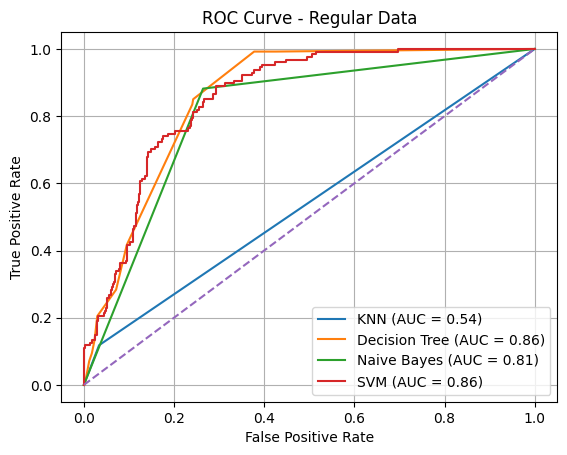

In [ ]:
# ROC CURVE - REGULAR DATA -80:20

data = regular_splits["80:20"]
X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train_clf"]
y_test  = data["y_test_clf"]

# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

plt.figure()

for name, model in models_roc.items():

    model.fit(X_train_scaled, y_train)

    # Get Probabilities
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_scores = model.decision_function(X_test_scaled)

    # ROC Calculation
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot Formatting
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Regular Data")
plt.legend()
plt.grid()
plt.show()

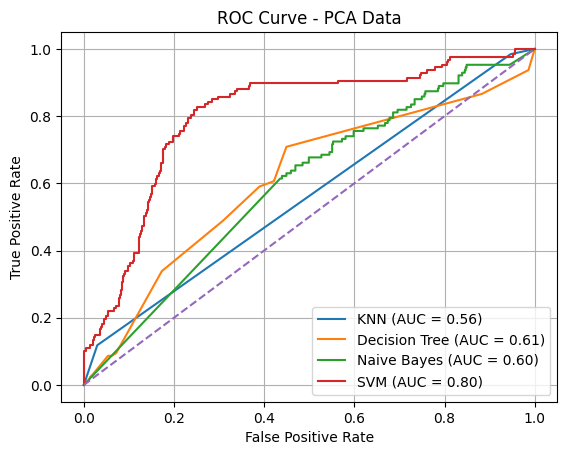

In [ ]:
# ROC CURVE - PCA DATA - 80:20
data = pca_splits["80:20"]
X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train_clf"]
y_test  = data["y_test_clf"]

plt.figure()

for name, model in models_roc.items():

    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        y_scores = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - PCA Data")
plt.legend()
plt.grid()
plt.show()

## CLUSTERING

In [ ]:
#Feature for clustering
cluster_features = [
    'Engagement Score',
    'Satisfaction Score',
    'Work-Life Balance Score',
    'Current Employee Rating',
    'Training Duration(Days)',
    'Training Cost'
]
# Select Features
X_cluster = df[cluster_features]

# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

In [ ]:
# PCA for Visualization
from sklearn.decomposition import PCA

pca_vis = PCA(n_components=2)

X_vis = pca_vis.fit_transform(X_cluster_scaled)

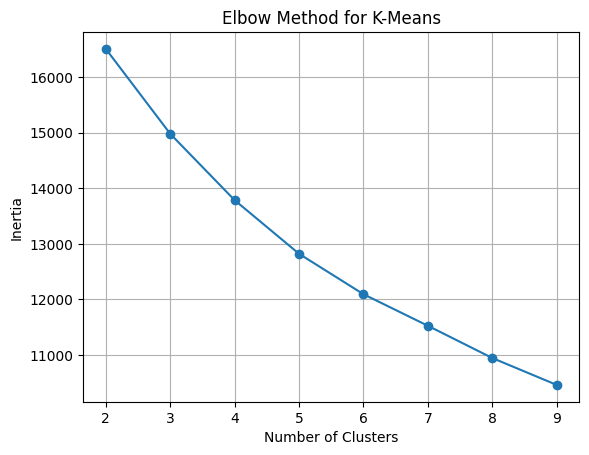

In [ ]:
# Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

k_range = range(2, 10)

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_cluster_scaled)

    inertia.append(kmeans.inertia_)

# Plot
plt.figure()

plt.plot(k_range, inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method for K-Means")

plt.grid()

plt.show()

In [ ]:
# K-Means Clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters_kmeans = kmeans.fit_predict(X_cluster_scaled)

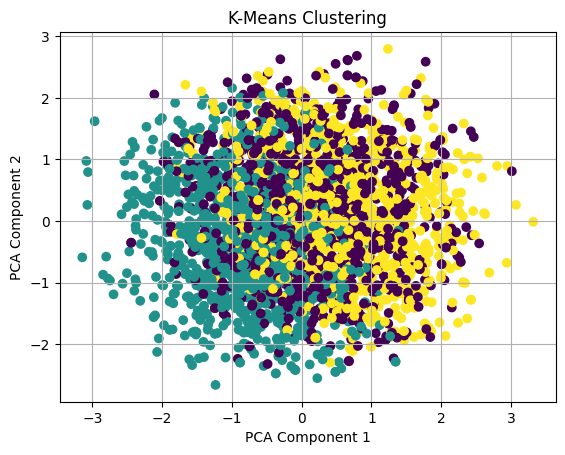

In [ ]:
# K-Means Cluster Plot
plt.figure()

plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=clusters_kmeans
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title("K-Means Clustering")

plt.grid()

plt.show()

In [ ]:
# K-Means Metrics
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

sil_kmeans = silhouette_score(
    X_cluster_scaled,
    clusters_kmeans
)

db_kmeans = davies_bouldin_score(
    X_cluster_scaled,
    clusters_kmeans
)

ch_kmeans = calinski_harabasz_score(
    X_cluster_scaled,
    clusters_kmeans
)

print("K-Means Performance")

print("Silhouette Score:", sil_kmeans)
print("Davies-Bouldin Score:", db_kmeans)
print("Calinski-Harabasz Score:", ch_kmeans)

K-Means Performance
Silhouette Score: 0.11684193106601155
Davies-Bouldin Score: 2.2083871257557077
Calinski-Harabasz Score: 411.68271717180903


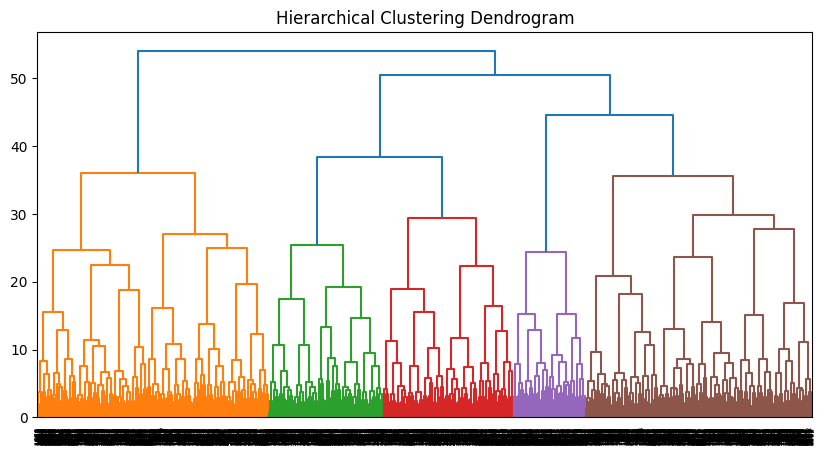

In [ ]:
#HIERARCHICAL CLUSTERING
# Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(
    X_cluster_scaled,
    method='ward'
)

plt.figure(figsize=(10, 5))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.show()

In [ ]:
# Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=3
)

clusters_hc = hc.fit_predict(X_cluster_scaled)

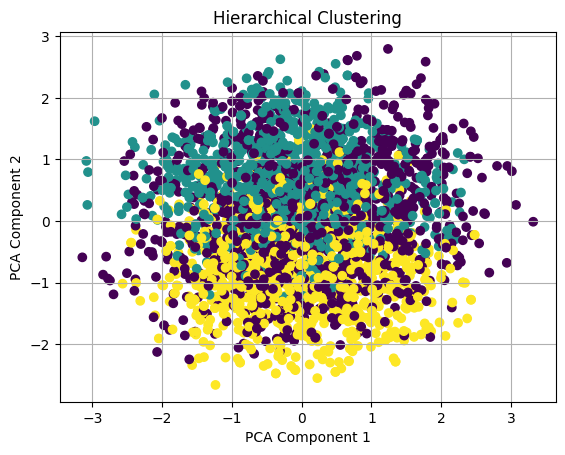

In [ ]:
# Hierarchical Cluster Plot
plt.figure()

plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=clusters_hc
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title("Hierarchical Clustering")

plt.grid()

plt.show()

In [ ]:
# Hierarchical Metrics
sil_hc = silhouette_score(
    X_cluster_scaled,
    clusters_hc
)

db_hc = davies_bouldin_score(
    X_cluster_scaled,
    clusters_hc
)

ch_hc = calinski_harabasz_score(
    X_cluster_scaled,
    clusters_hc
)

print("Hierarchical Performance")

print("Silhouette Score:", sil_hc)
print("Davies-Bouldin Score:", db_hc)
print("Calinski-Harabasz Score:", ch_hc)

Hierarchical Performance
Silhouette Score: 0.06957859680631122
Davies-Bouldin Score: 2.837798142051115
Calinski-Harabasz Score: 266.7813456777539


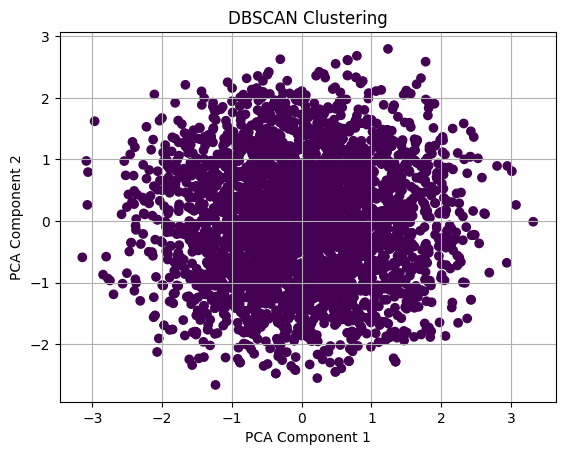

In [ ]:
# DBSCAN
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

clusters_dbscan = dbscan.fit_predict(X_cluster_scaled)

# DBSCAN Plot
plt.figure()

plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=clusters_dbscan
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title("DBSCAN Clustering")

plt.grid()

plt.show()

In [ ]:
# ------------------------------
# Clustering Comparison Table
# ------------------------------

cluster_results = pd.DataFrame({

    "Method": [
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],

    "Silhouette Score": [
        sil_kmeans,
        sil_hc,
        sil_dbscan
    ],

    "Davies-Bouldin Score": [
        db_kmeans,
        db_hc,
        db_dbscan
    ],

    "Calinski-Harabasz Score": [
        ch_kmeans,
        ch_hc,
        ch_dbscan
    ]
})

cluster_results

,Method,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score
0,K-Means,0.116842,2.208387,411.682717
1,Hierarchical,0.069579,2.837798,266.781346
2,DBSCAN,-1.000000,inf,-1.000000
